#### In the work available at https://www.cbr.ru/StaticHtml/File/115669/w_20250820.pdf (see Attachment N), there is a reference to the repository https://github.com/miabrahams/PricingTermStructure, which contains code for the US market.
#### In this notebook, I have adapted and extended that code for the RF yield curve, with the aim of obtaining the term premium.

In [466]:
import pandas as pd
import numpy as np
from numpy import newaxis
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import re
import matplotlib.pyplot as plt
from build_moex_curve import build_moex_curve
from ruonia import load_ruonia_1m, build_ruonia_monthly
from sklearn.decomposition import PCA
from numpy.linalg import inv
from statsmodels.tools.tools import add_constant

n_maturities = 120  
N_FACTORS=5
rx_maturities = (6, 18, 24, 36, 48, 60, 84, 120) 
# PARAMETRS
CLEAN_DIR = Path('.')
DEFAULT_DYNAMIC_PATH = CLEAN_DIR / 'data' / 'dynamic.csv'
DEFAULT_DAILY_OUTPUT = CLEAN_DIR / 'output' / 'moex_curve_daily.csv'
DEFAULT_MONTHLY_OUTPUT = CLEAN_DIR / 'output' / 'moex_curve_monthly.csv'
RUONIA_1M_PATH = CLEAN_DIR / 'data' / 'ruonia_1M.csv'
months = list(range(1, 121))
START_DATE = "2014-01-31"
END_DATE = "2024-05-31"


# Helper functions
def tenor_columns(df: pd.DataFrame) -> list[str]:
    return sorted(
        [c for c in df.columns if re.fullmatch(r"M\d{3}", c)],
        key=lambda c: int(c[1:]),
    )
    
def vec(x):
    return np.reshape(x, (-1, 1))
    
def vec_quad_form(x):
    return vec(np.outer(x, x))

def to_pyacm_curve(curve_df: pd.DataFrame) -> pd.DataFrame:
    df = curve_df.copy()
    df["date"] = pd.to_datetime(df["month_end"])
    df = df.set_index("date").sort_index()

    cols = tenor_columns(df)
    yield_curve = df[cols].copy()
    yield_curve.columns = [int(c[1:]) for c in cols]
    yield_curve = np.log1p(yield_curve / 100.0)

    yield_curve.index.name = "date"
    yield_curve.columns.name = "maturity_months"
    return yield_curve

In [ ]:
start_date = pd.to_datetime(START_DATE)
end_date = pd.to_datetime(END_DATE)

daily_curve, all_monthly_curve = build_moex_curve(
    dynamic_path=DEFAULT_DYNAMIC_PATH,
    daily_output_path=DEFAULT_DAILY_OUTPUT,
    monthly_output_path=DEFAULT_MONTHLY_OUTPUT,
    months=months,
)

all_monthly_curve["month_end"] = pd.to_datetime(all_monthly_curve["month_end"])

all_monthly_curve = (
    all_monthly_curve.loc[
        all_monthly_curve["month_end"].between(start_date, end_date, inclusive="both")
    ]
    .sort_values("month_end")
    .reset_index(drop=True)
)

all_monthly_curve["month"] = all_monthly_curve["month_end"].dt.to_period("M").astype(str)

ruonia_monthly = build_ruonia_monthly(load_ruonia_1m()).set_index("month_end")["short_rate_monthly_cc"]
yield_curve = to_pyacm_curve(all_monthly_curve)
data = pd.read_csv('data/key_rate_and_inflation.csv', parse_dates=['date'])

data["date"] = pd.to_datetime(data["date"], format="%m.%Y")
data["month_end"] = data["date"] + pd.offsets.MonthEnd(0)
data = data.set_index("month_end")

key_rate_1m_mean = np.log1p(data["key_rate"].resample("M").mean() / 100.0) / 12.0 
first_month_as_short_rate = np.log1p(yield_curve[1] / 100.0) / 12.0 
short_rate = key_rate_1m_mean

In [ ]:
yield_curve_df = yield_curve
yield_curve = yield_curve.values

In [ ]:
t = yield_curve.shape[0]-1
ttm = np.arange(1.0, n_maturities + 1.0)[newaxis, :] / 12.0
logPrices = - yield_curve * ttm
rf = -logPrices[:-1, [0]]
rx = logPrices[1:, :-1] - logPrices[:-1, 1:] - rf
scaledYields = StandardScaler(with_std=True).fit_transform(yield_curve)[:, 0:120]
scaledYieldCov = np.cov(scaledYields.T)
[eigenvalues, eigenvectors] = np.linalg.eig(scaledYieldCov)
yieldPCs = StandardScaler().fit_transform(scaledYields @ np.real(eigenvectors))
X = yieldPCs[:, 0:N_FACTORS].T
yieldPCs.shape, X.shape

((125, 120), (5, 125))

In [ ]:
# Step (1) of the three-step procedure: estimate VAR(1) for the time series of pricing factors.

X_lhs = X[:, 1:]  #X_t+1. Left hand side of VAR.
X_rhs = np.vstack((np.ones((1, t)), X[:, 0:-1])) #X_t and a constant.
var_coeffs = (X_lhs @ np.linalg.pinv(X_rhs))
mu = var_coeffs[:, [0]]
phi = var_coeffs[:, 1:]

v = X_lhs - var_coeffs @ X_rhs
Sigma = v @ v.T / t

In [ ]:
# Step (2) of the three-step procedure: regress log excess returns on the factors.
selected_rx = rx[:, [x - 2 for x in rx_maturities]].T  # Offset by 2 since index 0 is excess return on a 2m bond
N = selected_rx.shape[0]
Z = np.vstack((np.ones((1, t)), v, X[:, 0:-1]))  #Innovations and lagged X
abc = selected_rx @ np.linalg.pinv(Z)
E = selected_rx - abc @ Z
sigmasq_ret = np.sum(E * E) / E.size

a = abc[:, [0]]
beta = abc[:, 1:N_FACTORS+1].T
c = abc[:, N_FACTORS+1:]


In [ ]:
# Step (3) of the three-step procedure: Run cross-sectional regressions
BStar = np.squeeze(np.apply_along_axis(vec_quad_form, 1, beta.T))
lambda1 = np.linalg.pinv(beta.T) @ c
lambda0 = np.linalg.pinv(beta.T) @ (a + 1/2 * (BStar @ vec(Sigma) + sigmasq_ret))


In [ ]:
# Run bond pricing recursions
A = np.zeros((1, n_maturities))
B = np.zeros((N_FACTORS, n_maturities))


delta = rf.T @ np.linalg.pinv(np.vstack((np.ones((1, t)), X[:, 0:-1])))

delta0 = delta[[0], [0]]
delta1 = delta[[0], 1:]


A[0, 0] = - delta0
B[:, 0] = - delta1

for i in range(0, n_maturities - 1):
    A[0, i+1] = A[0, i] + B[:, i].T @ (mu - lambda0) + 1/2 * (B[:, i].T @ Sigma @ B[:, i] + 0 * sigmasq_ret) - delta0
    B[:, i+1] = B[:, i] @ (phi - lambda1) - delta1


/var/folders/cj/d68fmsfj3jj2j09286d43rth0000gn/T/ipykernel_74656/881385981.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  A[0, 0] = - delta0
/var/folders/cj/d68fmsfj3jj2j09286d43rth0000gn/T/ipykernel_74656/881385981.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  A[0, i+1] = A[0, i] + B[:, i].T @ (mu - lambda0) + 1/2 * (B[:, i].T @ Sigma @ B[:, i] + 0 * sigmasq_ret) - delta0


In [ ]:
# Run bond pricing recursions
Arn = np.zeros((1, n_maturities))
Brn = np.zeros((N_FACTORS, n_maturities))
lambda1 = np.zeros(lambda1.shape)
lambda0 = np.zeros(lambda0.shape)

delta = rf.T @ np.linalg.pinv(np.vstack((np.ones((1, t)), X[:, 0:-1])))

delta0 = delta[[0], [0]]
delta1 = delta[[0], 1:]


Arn[0, 0] = - delta0
Brn[:, 0] = - delta1

for i in range(0, n_maturities - 1):
    Arn[0, i+1] = Arn[0, i] + Brn[:, i].T @ (mu - lambda0) + 1/2 * (Brn[:, i].T @ Sigma @ Brn[:, i] + 0 * sigmasq_ret) - delta0
    Brn[:, i+1] = Brn[:, i] @ (phi - lambda1) - delta1


/var/folders/cj/d68fmsfj3jj2j09286d43rth0000gn/T/ipykernel_74656/3698854372.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Arn[0, 0] = - delta0
/var/folders/cj/d68fmsfj3jj2j09286d43rth0000gn/T/ipykernel_74656/3698854372.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Arn[0, i+1] = Arn[0, i] + Brn[:, i].T @ (mu - lambda0) + 1/2 * (Brn[:, i].T @ Sigma @ Brn[:, i] + 0 * sigmasq_ret) - delta0


In [ ]:
t_d = yield_curve.shape[0]

def compute_yields( A, B):
        A = A.reshape(-1, 1)
        multiplier = np.tile(yield_curve_df.columns / 12, (t_d, 1)).T
        F = yieldPCs[:, 0:N_FACTORS].T
        yields = (- ((np.tile(A, (1,t_d)) + B.T @ F) / multiplier).T)
        yields = pd.DataFrame(
            data=yields,
            index=yield_curve_df.index,
            columns=yield_curve_df.columns,
        )
        return yields

(125, 125)

In [ ]:
# Model Implied Yield
miy = compute_yields(A, B)

# Risk Neutral Yield
rny = compute_yields(Arn, Brn)

tp = miy - rny

Text(0.5, 1.0, 'Term Premium M120')

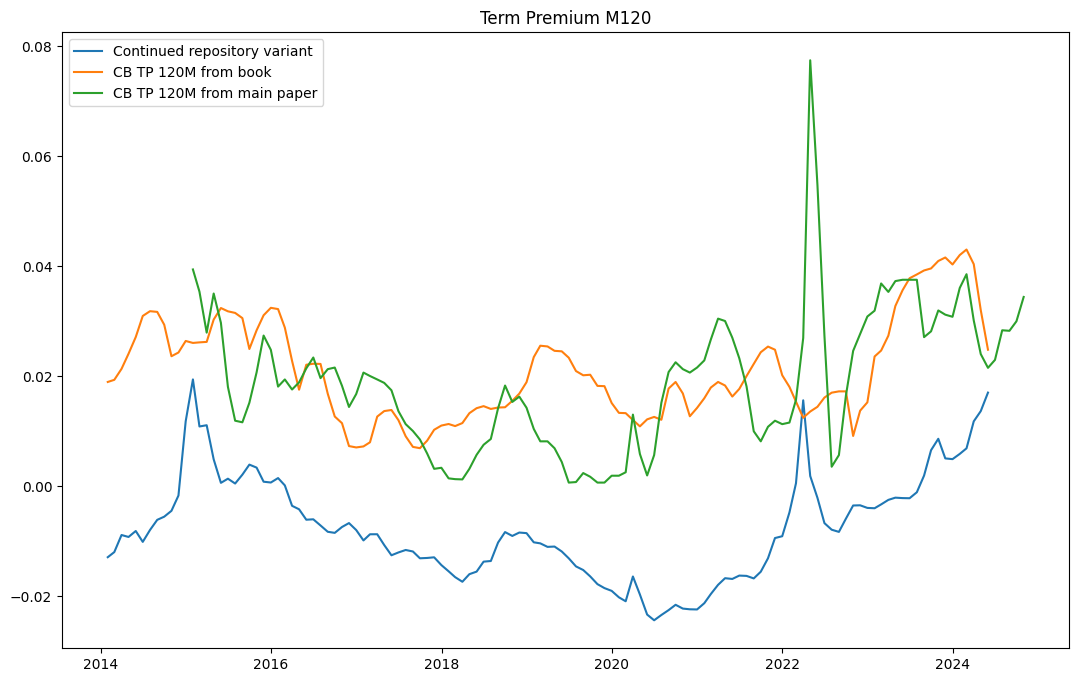

In [ ]:
plt.figure(figsize=(13, 8))
plt.plot(tp[120], label='Continued repository variant')
cb_tp = (
    pd.read_csv(Path("cb_tp/output/cb_tp_digitized_monthly.csv"), parse_dates=["date"])
    .rename(columns={"tp": "cb_tp"})
    .set_index("date")
)
cb_tp_book = (
    pd.read_csv(Path("cb_tp/output/tp_10y_book_digitized_monthly.csv"), index_col=['date'],parse_dates=['date'])
    .rename(columns={"tp": "cb_tp_book"})
    ['cb_tp_book'].loc[START_DATE : END_DATE]
    )
plt.plot(cb_tp_book/100, label='CB TP 120M from book')
plt.plot(cb_tp[cb_tp['tenor_years'] == 10]['cb_tp']/100, label='CB TP 120M from main paper')
plt.legend()
plt.title("Term Premium M120")